In [1]:
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# Common imports
import numpy as np
import os

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Where to save the figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "end_to_end_project"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

## Download the Data

In [2]:
import os
import tarfile
import urllib.request

DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
HOUSING_PATH = os.path.join("datasets", "housing")
HOUSING_URL = DOWNLOAD_ROOT + "datasets/housing/housing.tgz"

def fetch_housing_data(housing_url=HOUSING_URL, housing_path=HOUSING_PATH):
    if not os.path.isdir(housing_path):
        os.makedirs(housing_path)
    tgz_path = os.path.join(housing_path, "housing.tgz")
    urllib.request.urlretrieve(housing_url, tgz_path)
    housing_tgz = tarfile.open(tgz_path)
    housing_tgz.extractall(path=housing_path)
    housing_tgz.close()

fetch_housing_data()

In [3]:
import pandas as pd

def load_housing_data(housing_path=HOUSING_PATH):
    csv_path = os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path)

In [4]:
housing = load_housing_data()
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


Saving figure attribute_histogram_plots


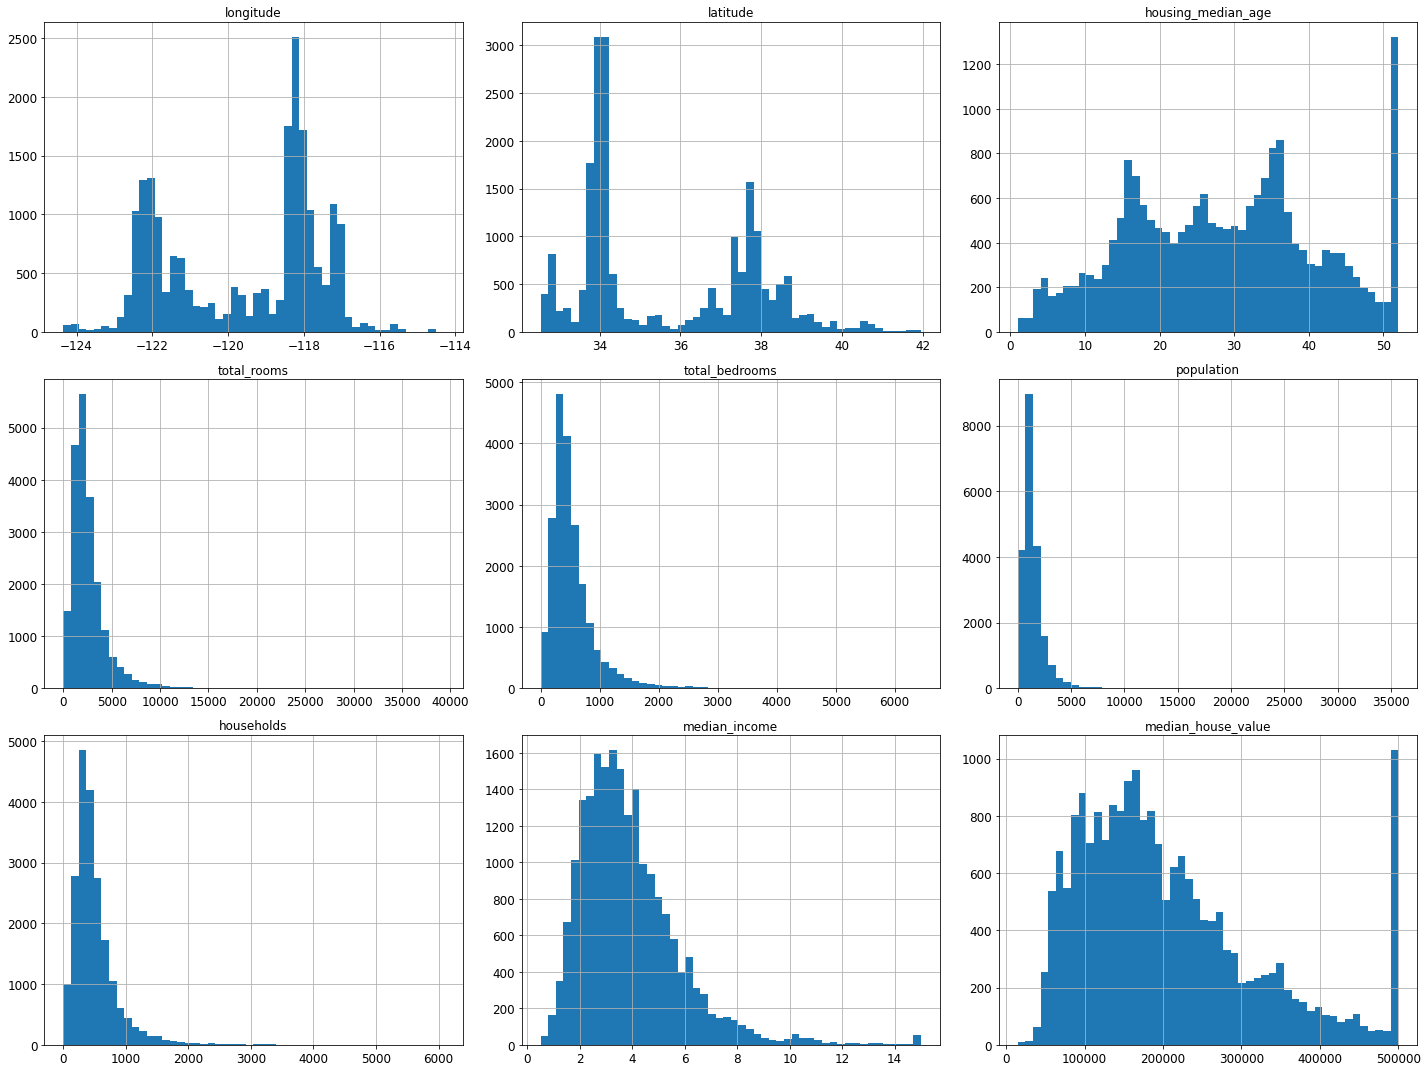

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
housing.hist(bins=50, figsize=(20,15))
save_fig("attribute_histogram_plots")
plt.show()

In [6]:
housing

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


## Calling train test split

In [7]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

## Splitting income categories to 5 groups

In [8]:
housing["income_cat"] = pd.cut(housing["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])


housing["income_cat"].value_counts()

income_cat
3    7236
2    6581
4    3639
5    2362
1     822
Name: count, dtype: int64

<Axes: >

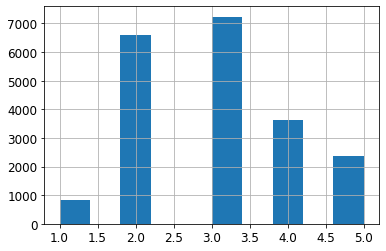

In [9]:
housing["income_cat"].hist()

## Calling stratified shuffle sampling 

In [10]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]

### proportion of each income category in your stratified test set

In [11]:
strat_test_set["income_cat"].value_counts() / len(strat_test_set)

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

### proportion of each income category in the full housing dataset

In [12]:
housing["income_cat"].value_counts() / len(housing)

income_cat
3    0.350581
2    0.318847
4    0.176308
5    0.114438
1    0.039826
Name: count, dtype: float64

In [13]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

In [14]:
housing = strat_train_set.copy()

## Visualizing Geographical Data

Saving figure housing_prices_scatterplot


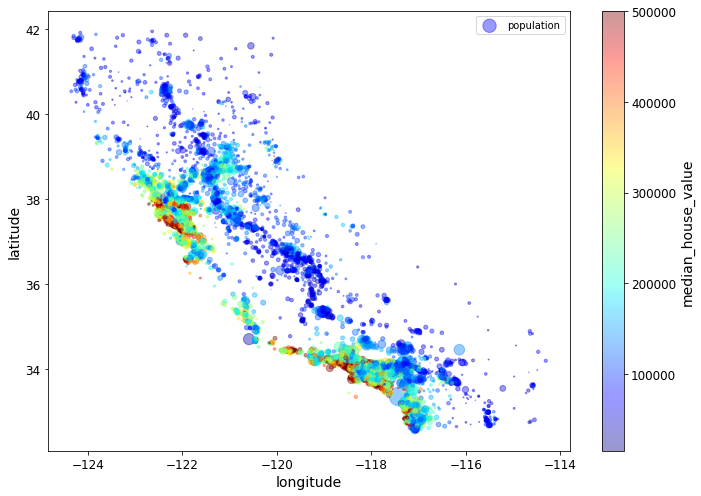

In [15]:
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
             s=housing["population"]/100, label="population", figsize=(10,7),
             c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True,
             sharex=False)
plt.legend()
save_fig("housing_prices_scatterplot")

## Download the California image

In [16]:
images_path = os.path.join(PROJECT_ROOT_DIR, "images", "end_to_end_project")
os.makedirs(images_path, exist_ok=True)
DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
filename = "california.png"
print("Downloading", filename)
url = DOWNLOAD_ROOT + "images/end_to_end_project/" + filename
urllib.request.urlretrieve(url, os.path.join(images_path, filename))

('.\\images\\end_to_end_project\\california.png',
 <http.client.HTTPMessage at 0x1e5e44b8490>)

Saving figure california_housing_prices_plot


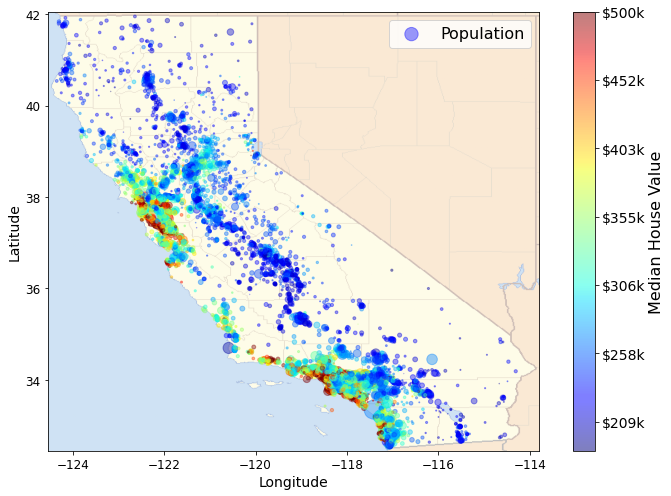

In [17]:


import matplotlib.image as mpimg
california_img=mpimg.imread(os.path.join(images_path, filename))
ax = housing.plot(kind="scatter", x="longitude", y="latitude", figsize=(10,7),
                  s=housing['population']/100, label="Population",
                  c="median_house_value", cmap=plt.get_cmap("jet"),
                  colorbar=False, alpha=0.4)
plt.imshow(california_img, extent=[-124.55, -113.80, 32.45, 42.05], alpha=0.5,
           cmap=plt.get_cmap("jet"))
plt.ylabel("Latitude", fontsize=14)
plt.xlabel("Longitude", fontsize=14)

prices = housing["median_house_value"]
tick_values = np.linspace(prices.min(), prices.max(), 11)
cbar = plt.colorbar(ticks=tick_values/prices.max())
cbar.ax.set_yticklabels(["$%dk"%(round(v/1000)) for v in tick_values], fontsize=14)
cbar.set_label('Median House Value', fontsize=16)

plt.legend(fontsize=16)
save_fig("california_housing_prices_plot")
plt.show()

## Experimenting with Attribute Combinations

In [18]:
housing["rooms_per_household"] = housing["total_rooms"]/housing["households"]
housing["bedrooms_per_room"] = housing["total_bedrooms"]/housing["total_rooms"]
housing["population_per_household"]=housing["population"]/housing["households"]

## Prepare the Data for Machine Learning Algorithms

In [19]:
housing = strat_train_set.drop("median_house_value", axis=1)  # features
housing_labels = strat_train_set["median_house_value"].copy()  # target

## Define CombinedAttributesAdder

In [20]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_bedrooms_per_room=True):
        self.add_bedrooms_per_room = add_bedrooms_per_room

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # Indices for columns: ["total_rooms", "total_bedrooms", "population", "households"]
        rooms_per_household = X[:, 0] / X[:, 3]
        population_per_household = X[:, 2] / X[:, 3]
        if self.add_bedrooms_per_room:
            bedrooms_per_room = X[:, 1] / X[:, 0]
            return np.c_[X, rooms_per_household, population_per_household, bedrooms_per_room]
        else:
            return np.c_[X, rooms_per_household, population_per_household]

In [21]:
#  Select numeric and categorical columns
num_attribs = list(housing.select_dtypes(include=[np.number]))
cat_attribs = ["ocean_proximity"]

## numeric pipeline

In [22]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),  
    ('attribs_adder', CombinedAttributesAdder()),   
    ('std_scaler', StandardScaler()),               
])

## Combine numeric and categorical pipelines

In [23]:
full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", OneHotEncoder(), cat_attribs),
])

In [24]:
housing_prepared = full_pipeline.fit_transform(housing)

In [25]:
print(housing_prepared.shape)

(16512, 16)


# Select and Train a Model

## Training and Evaluating on the Training Set

In [26]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(housing_prepared, housing_labels)

LinearRegression()

In [27]:
from sklearn.metrics import mean_squared_error

housing_predictions = lin_reg.predict(housing_prepared)
lin_mse = mean_squared_error(housing_labels, housing_predictions)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

68636.17673607037

In [28]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(housing_prepared, housing_labels)

DecisionTreeRegressor(random_state=42)

## Better Evaluation Using Cross-Validation

In [29]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(tree_reg, housing_prepared, housing_labels,
                         scoring="neg_mean_squared_error", cv=10)
tree_rmse_scores = np.sqrt(-scores)

In [30]:
def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())

display_scores(tree_rmse_scores)

Scores: [66908.34202916 68053.62068381 70103.51466702 68641.00033156
 67345.18313865 69190.76843412 72609.75497179 68045.39448065
 67322.50559764 71241.4696124 ]
Mean: 68946.15539468042
Standard deviation: 1764.73475149664


In [31]:
lin_scores = cross_val_score(lin_reg, housing_prepared, housing_labels,
                             scoring="neg_mean_squared_error", cv=10)
lin_rmse_scores = np.sqrt(-lin_scores)
display_scores(lin_rmse_scores)

Scores: [71892.9149708  64961.0020587  67631.7973089  68546.57031719
 66446.90774065 72607.10354598 70288.8282852  68588.44975879
 68743.18520029 70440.80394608]
Mean: 69014.7563132575
Standard deviation: 2241.866607758548


In [32]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = RandomForestRegressor(n_estimators=100, random_state=42)
forest_reg.fit(housing_prepared, housing_labels)

RandomForestRegressor(random_state=42)

In [33]:
housing_predictions = forest_reg.predict(housing_prepared)
forest_mse = mean_squared_error(housing_labels, housing_predictions)
forest_rmse = np.sqrt(forest_mse)
forest_rmse

18178.41046937676

In [34]:
from sklearn.model_selection import cross_val_score


forest_scores = cross_val_score(forest_reg, housing_prepared, housing_labels,
                                scoring="neg_mean_squared_error", cv=10)
forest_rmse_scores = np.sqrt(-forest_scores)
display_scores(forest_rmse_scores)

Scores: [50494.07067484 49199.76913901 45179.55533628 50085.65839486
 47206.0897955  48496.65729931 50951.65116525 47785.88762521
 46842.89956152 52355.86484262]
Mean: 48859.8103834404
Standard deviation: 2062.024858057841


In [35]:
from sklearn.svm import SVR

svm_reg = SVR(kernel="linear")
svm_reg.fit(housing_prepared, housing_labels)
housing_predictions = svm_reg.predict(housing_prepared)
svm_mse = mean_squared_error(housing_labels, housing_predictions)
svm_rmse = np.sqrt(svm_mse)
svm_rmse

111449.85129969762

# Fine-Tune Your Model

## Grid Search

In [36]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    # try 12 (3×4) combinations of hyperparameters
    {'n_estimators': [3, 10, 30], 'max_features': [2, 4, 6, 8]},
    # then try 6 (2×3) combinations with bootstrap set as False
    {'bootstrap': [False], 'n_estimators': [3, 10], 'max_features': [2, 3, 4]},
  ]

forest_reg = RandomForestRegressor(random_state=42)
# train across 5 folds, that's a total of (12+6)*5=90 rounds of training 
grid_search = GridSearchCV(forest_reg, param_grid, cv=5,
                           scoring='neg_mean_squared_error',
                           return_train_score=True)
grid_search.fit(housing_prepared, housing_labels)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid=[{'max_features': [2, 4, 6, 8],
                          'n_estimators': [3, 10, 30]},
                         {'bootstrap': [False], 'max_features': [2, 3, 4],
                          'n_estimators': [3, 10]}],
             return_train_score=True, scoring='neg_mean_squared_error')

In [37]:
grid_search.best_params_

{'max_features': 6, 'n_estimators': 30}

In [38]:
grid_search.best_estimator_

RandomForestRegressor(max_features=6, n_estimators=30, random_state=42)

In [39]:
cvres = grid_search.cv_results_
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print(np.sqrt(-mean_score), params)

64610.19092568027 {'max_features': 2, 'n_estimators': 3}
54890.65682750992 {'max_features': 2, 'n_estimators': 10}
52543.73041515637 {'max_features': 2, 'n_estimators': 30}
58929.625749787934 {'max_features': 4, 'n_estimators': 3}
51166.64430884052 {'max_features': 4, 'n_estimators': 10}
49357.56415075921 {'max_features': 4, 'n_estimators': 30}
57145.88898790625 {'max_features': 6, 'n_estimators': 3}
50608.05854236457 {'max_features': 6, 'n_estimators': 10}
48775.22929715454 {'max_features': 6, 'n_estimators': 30}
58344.502748215215 {'max_features': 8, 'n_estimators': 3}
51698.54837417664 {'max_features': 8, 'n_estimators': 10}
49229.818493552055 {'max_features': 8, 'n_estimators': 30}
62384.77991881558 {'bootstrap': False, 'max_features': 2, 'n_estimators': 3}
53593.46403343733 {'bootstrap': False, 'max_features': 2, 'n_estimators': 10}
58651.23177142072 {'bootstrap': False, 'max_features': 3, 'n_estimators': 3}
52083.42093779026 {'bootstrap': False, 'max_features': 3, 'n_estimators':

In [40]:
pd.DataFrame(grid_search.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_features,param_n_estimators,param_bootstrap,params,split0_test_score,split1_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.221569,0.008403,0.004004,0.001987,2,3,NaN,"{'max_features': 2, 'n_estimators': 3}",-4.231790e+09,-4.266036e+09,...,-4.174477e+09,1.287597e+08,18,-1.201043e+09,-1.205186e+09,-1.133103e+09,-1.142141e+09,-1.136837e+09,-1.163662e+09,3.236719e+07
1,0.771809,0.046635,0.008812,0.000773,2,10,NaN,"{'max_features': 2, 'n_estimators': 10}",-2.985058e+09,-3.015540e+09,...,-3.012984e+09,8.473737e+07,11,-5.893102e+08,-5.985336e+08,-5.810291e+08,-5.764089e+08,-5.868584e+08,-5.864280e+08,7.544137e+06
2,2.258632,0.076512,0.024309,0.000767,2,30,NaN,"{'max_features': 2, 'n_estimators': 30}",-2.757295e+09,-2.627692e+09,...,-2.760844e+09,7.836288e+07,9,-4.305770e+08,-4.338904e+08,-4.311203e+08,-4.298097e+08,-4.294258e+08,-4.309646e+08,1.577110e+06
3,0.370238,0.010607,0.003560,0.000503,4,3,NaN,"{'max_features': 4, 'n_estimators': 3}",-3.639317e+09,-3.237306e+09,...,-3.472701e+09,1.602887e+08,16,-9.582940e+08,-9.381971e+08,-9.515088e+08,-9.610414e+08,-9.165311e+08,-9.451145e+08,1.632861e+07
4,1.271961,0.059205,0.009176,0.000981,4,10,NaN,"{'max_features': 4, 'n_estimators': 10}",-2.717490e+09,-2.494820e+09,...,-2.618025e+09,8.488572e+07,6,-5.161472e+08,-5.140200e+08,-4.999597e+08,-5.062848e+08,-5.005204e+08,-5.073864e+08,6.697256e+06
5,3.718424,0.088286,0.024142,0.001178,4,30,NaN,"{'max_features': 4, 'n_estimators': 30}",-2.433800e+09,-2.338016e+09,...,-2.436169e+09,5.796629e+07,3,-3.872475e+08,-3.847704e+08,-3.768198e+08,-3.728828e+08,-3.764797e+08,-3.796400e+08,5.436849e+06
6,0.524466,0.025779,0.003892,0.000665,6,3,NaN,"{'max_features': 6, 'n_estimators': 3}",-3.268439e+09,-3.375823e+09,...,-3.265653e+09,9.827750e+07,12,-8.500015e+08,-9.242236e+08,-9.021590e+08,-8.861933e+08,-8.717829e+08,-8.868721e+08,2.536301e+07
7,1.805131,0.074430,0.009329,0.000999,6,10,NaN,"{'max_features': 6, 'n_estimators': 10}",-2.652830e+09,-2.489392e+09,...,-2.561176e+09,8.944591e+07,5,-4.852023e+08,-4.963469e+08,-4.686344e+08,-4.855568e+08,-4.913889e+08,-4.854259e+08,9.347162e+06
8,5.368041,0.135636,0.024776,0.002222,6,30,NaN,"{'max_features': 6, 'n_estimators': 30}",-2.380472e+09,-2.281405e+09,...,-2.379023e+09,6.368183e+07,1,-3.657263e+08,-3.753112e+08,-3.676424e+08,-3.713037e+08,-3.651090e+08,-3.690185e+08,3.816701e+06
9,0.742968,0.027083,0.003601,0.000482,8,3,NaN,"{'max_features': 8, 'n_estimators': 3}",-3.397678e+09,-3.340458e+09,...,-3.404081e+09,5.376529e+07,13,-9.078260e+08,-9.166009e+08,-9.304834e+08,-8.899572e+08,-9.039424e+08,-9.097620e+08,1.346102e+07


In [41]:
feature_importances = grid_search.best_estimator_.feature_importances_
feature_importances

array([1.05491119e-01, 7.40382961e-02, 3.81802802e-02, 2.27947565e-02,
       2.19298572e-02, 3.51089792e-02, 2.08369392e-02, 3.92569364e-01,
       2.10344439e-02, 2.23306427e-02, 9.52843928e-02, 9.20135338e-03,
       1.34268949e-01, 3.72048098e-05, 1.31702826e-03, 5.57639368e-03])

In [42]:
extra_attribs = ["rooms_per_hhold", "pop_per_hhold", "bedrooms_per_room"]
#cat_encoder = cat_pipeline.named_steps["cat_encoder"] # old solution
cat_encoder = full_pipeline.named_transformers_["cat"]
cat_one_hot_attribs = list(cat_encoder.categories_[0])
attributes = num_attribs + extra_attribs + cat_one_hot_attribs
sorted(zip(feature_importances, attributes), reverse=True)

[(0.39256936447589885, 'median_income'),
 (0.13426894857253455, 'INLAND'),
 (0.10549111898315708, 'longitude'),
 (0.09528439276776134, 'bedrooms_per_room'),
 (0.07403829610544493, 'latitude'),
 (0.038180280238152564, 'housing_median_age'),
 (0.03510897920312309, 'population'),
 (0.02279475648609725, 'total_rooms'),
 (0.022330642699655404, 'pop_per_hhold'),
 (0.021929857212572228, 'total_bedrooms'),
 (0.02103444388548311, 'rooms_per_hhold'),
 (0.020836939235784873, 'households'),
 (0.009201353383200963, '<1H OCEAN'),
 (0.005576393677393563, 'NEAR OCEAN'),
 (0.0013170282639010185, 'NEAR BAY'),
 (3.720480983919306e-05, 'ISLAND')]

## Evaluate Your System on the Test Set

In [43]:
final_model = grid_search.best_estimator_

X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()

X_test_prepared = full_pipeline.transform(X_test)
final_predictions = final_model.predict(X_test_prepared)

final_mse = mean_squared_error(y_test, final_predictions)
final_rmse = np.sqrt(final_mse)

final_rmse

46269.454387661295

In [44]:
from scipy import stats

confidence = 0.95
squared_errors = (final_predictions - y_test) ** 2
np.sqrt(stats.t.interval(confidence, len(squared_errors) - 1,
                         loc=squared_errors.mean(),
                         scale=stats.sem(squared_errors)))

array([44379.92932883, 48084.78648629])

### """
Use a Support Vector Regression (SVR) model from sklearn.svm.SVR and experiment with different hyperparameter settings.
Try the following:

Use kernel = "linear" and test several values for the C parameter.

Use kernel = "rbf" and test multiple combinations of C and gamma values.
"""

In [45]:
from sklearn.model_selection import GridSearchCV

param_grid = [
        {'kernel': ['linear'], 'C': [10., 30., 100., 300., 1000., 3000., 10000., 30000.0]},
        {'kernel': ['rbf'], 'C': [1.0, 3.0, 10., 30., 100., 300., 1000.0],
         'gamma': [0.01, 0.03, 0.1, 0.3, 1.0, 3.0]},
    ]

svm_reg = SVR()
grid_search = GridSearchCV(svm_reg, param_grid, cv=5, scoring='neg_mean_squared_error', verbose=2)
grid_search.fit(housing_prepared, housing_labels)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END ..............................C=10.0, kernel=linear; total time=   6.8s
[CV] END ..............................C=10.0, kernel=linear; total time=   7.1s
[CV] END ..............................C=10.0, kernel=linear; total time=   6.8s
[CV] END ..............................C=10.0, kernel=linear; total time=   6.7s
[CV] END ..............................C=10.0, kernel=linear; total time=   7.0s
[CV] END ..............................C=30.0, kernel=linear; total time=   6.8s
[CV] END ..............................C=30.0, kernel=linear; total time=   6.8s
[CV] END ..............................C=30.0, kernel=linear; total time=   7.1s
[CV] END ..............................C=30.0, kernel=linear; total time=   7.0s
[CV] END ..............................C=30.0, kernel=linear; total time=   7.5s
[CV] END .............................C=100.0, kernel=linear; total time=   6.7s
[CV] END .............................C=100.0, 

[CV] END .....................C=10.0, gamma=0.01, kernel=rbf; total time=  14.2s
[CV] END .....................C=10.0, gamma=0.01, kernel=rbf; total time=  13.0s
[CV] END .....................C=10.0, gamma=0.01, kernel=rbf; total time=  14.6s
[CV] END .....................C=10.0, gamma=0.01, kernel=rbf; total time=  14.9s
[CV] END .....................C=10.0, gamma=0.03, kernel=rbf; total time=  14.3s
[CV] END .....................C=10.0, gamma=0.03, kernel=rbf; total time=  14.8s
[CV] END .....................C=10.0, gamma=0.03, kernel=rbf; total time=  13.7s
[CV] END .....................C=10.0, gamma=0.03, kernel=rbf; total time=  14.2s
[CV] END .....................C=10.0, gamma=0.03, kernel=rbf; total time=  14.5s
[CV] END ......................C=10.0, gamma=0.1, kernel=rbf; total time=  14.5s
[CV] END ......................C=10.0, gamma=0.1, kernel=rbf; total time=  14.2s
[CV] END ......................C=10.0, gamma=0.1, kernel=rbf; total time=  13.3s
[CV] END ...................

[CV] END .....................C=300.0, gamma=0.1, kernel=rbf; total time=  14.4s
[CV] END .....................C=300.0, gamma=0.1, kernel=rbf; total time=  14.2s
[CV] END .....................C=300.0, gamma=0.3, kernel=rbf; total time=  14.4s
[CV] END .....................C=300.0, gamma=0.3, kernel=rbf; total time=  13.9s
[CV] END .....................C=300.0, gamma=0.3, kernel=rbf; total time=  14.1s
[CV] END .....................C=300.0, gamma=0.3, kernel=rbf; total time=  14.2s
[CV] END .....................C=300.0, gamma=0.3, kernel=rbf; total time=  14.0s
[CV] END .....................C=300.0, gamma=1.0, kernel=rbf; total time=  14.2s
[CV] END .....................C=300.0, gamma=1.0, kernel=rbf; total time=  14.0s
[CV] END .....................C=300.0, gamma=1.0, kernel=rbf; total time=  14.0s
[CV] END .....................C=300.0, gamma=1.0, kernel=rbf; total time=  14.3s
[CV] END .....................C=300.0, gamma=1.0, kernel=rbf; total time=  14.5s
[CV] END ...................

GridSearchCV(cv=5, estimator=SVR(),
             param_grid=[{'C': [10.0, 30.0, 100.0, 300.0, 1000.0, 3000.0,
                                10000.0, 30000.0],
                          'kernel': ['linear']},
                         {'C': [1.0, 3.0, 10.0, 30.0, 100.0, 300.0, 1000.0],
                          'gamma': [0.01, 0.03, 0.1, 0.3, 1.0, 3.0],
                          'kernel': ['rbf']}],
             scoring='neg_mean_squared_error', verbose=2)

In [46]:
negative_mse = grid_search.best_score_
rmse = np.sqrt(-negative_mse)
rmse

70467.38185697672

In [47]:
grid_search.best_params_

{'C': 30000.0, 'kernel': 'linear'}

In [48]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import expon, reciprocal

# see https://docs.scipy.org/doc/scipy/reference/stats.html
# for `expon()` and `reciprocal()` documentation and more probability distribution functions.

# Note: gamma is ignored when kernel is "linear"
param_distribs = {
        'kernel': ['linear', 'rbf'],
        'C': reciprocal(20, 200000),
        'gamma': expon(scale=1.0),
    }

svm_reg = SVR()
rnd_search = RandomizedSearchCV(svm_reg, param_distributions=param_distribs,
                                n_iter=50, cv=5, scoring='neg_mean_squared_error',
                                verbose=2, random_state=42)
rnd_search.fit(housing_prepared, housing_labels)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END C=629.782329591372, gamma=3.010121430917521, kernel=linear; total time=   7.9s
[CV] END C=629.782329591372, gamma=3.010121430917521, kernel=linear; total time=   7.8s
[CV] END C=629.782329591372, gamma=3.010121430917521, kernel=linear; total time=   7.9s
[CV] END C=629.782329591372, gamma=3.010121430917521, kernel=linear; total time=   8.1s
[CV] END C=629.782329591372, gamma=3.010121430917521, kernel=linear; total time=   7.7s
[CV] END C=26290.206464300216, gamma=0.9084469696321253, kernel=rbf; total time=  16.7s
[CV] END C=26290.206464300216, gamma=0.9084469696321253, kernel=rbf; total time=  16.5s
[CV] END C=26290.206464300216, gamma=0.9084469696321253, kernel=rbf; total time=  17.3s
[CV] END C=26290.206464300216, gamma=0.9084469696321253, kernel=rbf; total time=  17.0s
[CV] END C=26290.206464300216, gamma=0.9084469696321253, kernel=rbf; total time=  16.6s
[CV] END C=84.14107900575871, gamma=0.059838768608680676, 

[CV] END C=8935.505635947808, gamma=0.37354658165762367, kernel=rbf; total time=  12.9s
[CV] END C=8935.505635947808, gamma=0.37354658165762367, kernel=rbf; total time=  12.6s
[CV] END C=8935.505635947808, gamma=0.37354658165762367, kernel=rbf; total time=  12.5s
[CV] END C=135.76775824842434, gamma=0.838636245624803, kernel=linear; total time=   7.0s
[CV] END C=135.76775824842434, gamma=0.838636245624803, kernel=linear; total time=   6.6s
[CV] END C=135.76775824842434, gamma=0.838636245624803, kernel=linear; total time=   6.8s
[CV] END C=135.76775824842434, gamma=0.838636245624803, kernel=linear; total time=   6.6s
[CV] END C=135.76775824842434, gamma=0.838636245624803, kernel=linear; total time=   7.1s
[CV] END C=151136.20282548846, gamma=1.4922453771381408, kernel=rbf; total time= 1.6min
[CV] END C=151136.20282548846, gamma=1.4922453771381408, kernel=rbf; total time= 2.0min
[CV] END C=151136.20282548846, gamma=1.4922453771381408, kernel=rbf; total time= 1.5min
[CV] END C=151136.2028

[CV] END C=60.17373642891687, gamma=1.2491263443165994, kernel=linear; total time=   7.2s
[CV] END C=15415.161544891856, gamma=0.2691677514619319, kernel=rbf; total time=  13.6s
[CV] END C=15415.161544891856, gamma=0.2691677514619319, kernel=rbf; total time=  13.3s
[CV] END C=15415.161544891856, gamma=0.2691677514619319, kernel=rbf; total time=  13.5s
[CV] END C=15415.161544891856, gamma=0.2691677514619319, kernel=rbf; total time=  13.7s
[CV] END C=15415.161544891856, gamma=0.2691677514619319, kernel=rbf; total time=  13.7s
[CV] END C=1888.9148509967113, gamma=0.739678838777267, kernel=linear; total time=   7.5s
[CV] END C=1888.9148509967113, gamma=0.739678838777267, kernel=linear; total time=   7.5s
[CV] END C=1888.9148509967113, gamma=0.739678838777267, kernel=linear; total time=   7.7s
[CV] END C=1888.9148509967113, gamma=0.739678838777267, kernel=linear; total time=   7.7s
[CV] END C=1888.9148509967113, gamma=0.739678838777267, kernel=linear; total time=   7.1s
[CV] END C=55.538389

RandomizedSearchCV(cv=5, estimator=SVR(), n_iter=50,
                   param_distributions={'C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001E5E62979A0>,
                                        'gamma': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001E5E62A1E20>,
                                        'kernel': ['linear', 'rbf']},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

## """Try using RandomizedSearchCV instead of GridSearchCV"""

In [49]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import expon, reciprocal

# see https://docs.scipy.org/doc/scipy/reference/stats.html
# for `expon()` and `reciprocal()` documentation and more probability distribution functions.

# Note: gamma is ignored when kernel is "linear"
param_distribs = {
        'kernel': ['linear', 'rbf'],
        'C': reciprocal(20, 200000),
        'gamma': expon(scale=1.0),
    }

svm_reg = SVR()
rnd_search = RandomizedSearchCV(svm_reg, param_distributions=param_distribs,
                                n_iter=50, cv=5, scoring='neg_mean_squared_error',
                                verbose=2, random_state=42)
rnd_search.fit(housing_prepared, housing_labels)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END C=629.782329591372, gamma=3.010121430917521, kernel=linear; total time=   6.9s
[CV] END C=629.782329591372, gamma=3.010121430917521, kernel=linear; total time=   6.6s
[CV] END C=629.782329591372, gamma=3.010121430917521, kernel=linear; total time=   7.1s
[CV] END C=629.782329591372, gamma=3.010121430917521, kernel=linear; total time=   7.2s
[CV] END C=629.782329591372, gamma=3.010121430917521, kernel=linear; total time=   7.1s
[CV] END C=26290.206464300216, gamma=0.9084469696321253, kernel=rbf; total time=  15.4s
[CV] END C=26290.206464300216, gamma=0.9084469696321253, kernel=rbf; total time=  14.6s
[CV] END C=26290.206464300216, gamma=0.9084469696321253, kernel=rbf; total time=  16.4s
[CV] END C=26290.206464300216, gamma=0.9084469696321253, kernel=rbf; total time=  15.2s
[CV] END C=26290.206464300216, gamma=0.9084469696321253, kernel=rbf; total time=  16.0s
[CV] END C=84.14107900575871, gamma=0.059838768608680676, 

[CV] END C=8935.505635947808, gamma=0.37354658165762367, kernel=rbf; total time=  13.2s
[CV] END C=8935.505635947808, gamma=0.37354658165762367, kernel=rbf; total time=  12.6s
[CV] END C=8935.505635947808, gamma=0.37354658165762367, kernel=rbf; total time=  13.3s
[CV] END C=135.76775824842434, gamma=0.838636245624803, kernel=linear; total time=   6.6s
[CV] END C=135.76775824842434, gamma=0.838636245624803, kernel=linear; total time=   6.7s
[CV] END C=135.76775824842434, gamma=0.838636245624803, kernel=linear; total time=   6.7s
[CV] END C=135.76775824842434, gamma=0.838636245624803, kernel=linear; total time=   6.8s
[CV] END C=135.76775824842434, gamma=0.838636245624803, kernel=linear; total time=   7.6s
[CV] END C=151136.20282548846, gamma=1.4922453771381408, kernel=rbf; total time= 1.7min
[CV] END C=151136.20282548846, gamma=1.4922453771381408, kernel=rbf; total time= 1.8min
[CV] END C=151136.20282548846, gamma=1.4922453771381408, kernel=rbf; total time= 1.5min
[CV] END C=151136.2028

[CV] END C=60.17373642891687, gamma=1.2491263443165994, kernel=linear; total time=   6.6s
[CV] END C=15415.161544891856, gamma=0.2691677514619319, kernel=rbf; total time=  13.0s
[CV] END C=15415.161544891856, gamma=0.2691677514619319, kernel=rbf; total time=  12.7s
[CV] END C=15415.161544891856, gamma=0.2691677514619319, kernel=rbf; total time=  13.1s
[CV] END C=15415.161544891856, gamma=0.2691677514619319, kernel=rbf; total time=  12.9s
[CV] END C=15415.161544891856, gamma=0.2691677514619319, kernel=rbf; total time=  12.8s
[CV] END C=1888.9148509967113, gamma=0.739678838777267, kernel=linear; total time=   6.9s
[CV] END C=1888.9148509967113, gamma=0.739678838777267, kernel=linear; total time=   7.0s
[CV] END C=1888.9148509967113, gamma=0.739678838777267, kernel=linear; total time=   7.3s
[CV] END C=1888.9148509967113, gamma=0.739678838777267, kernel=linear; total time=   7.7s
[CV] END C=1888.9148509967113, gamma=0.739678838777267, kernel=linear; total time=   7.1s
[CV] END C=55.538389

RandomizedSearchCV(cv=5, estimator=SVR(), n_iter=50,
                   param_distributions={'C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001E5E62C89A0>,
                                        'gamma': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001E5E629ED90>,
                                        'kernel': ['linear', 'rbf']},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

In [50]:
negative_mse = rnd_search.best_score_
rmse = np.sqrt(-negative_mse)
rmse

54507.93785247265

In [51]:
rnd_search.best_params_

{'C': 157055.10989448498, 'gamma': 0.26497040005002437, 'kernel': 'rbf'}

## """Try adding a transformer in the preparation pipeline to select only the most important attributes."""

In [52]:
from sklearn.base import BaseEstimator, TransformerMixin

def indices_of_top_k(arr, k):
    return np.sort(np.argpartition(np.array(arr), -k)[-k:])

class TopFeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, feature_importances, k):
        self.feature_importances = feature_importances
        self.k = k
    def fit(self, X, y=None):
        self.feature_indices_ = indices_of_top_k(self.feature_importances, self.k)
        return self
    def transform(self, X):
        return X[:, self.feature_indices_]

## """Function to get indices of top-k features"""

In [53]:
def indices_of_top_k(arr, k):
    return np.sort(np.argpartition(np.array(arr), -k)[-k:])

In [54]:
class TopFeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, feature_importances, k):
        self.feature_importances = feature_importances
        self.k = k

    def fit(self, X, y=None):
        self.feature_indices_ = indices_of_top_k(self.feature_importances, self.k)
        return self

    def transform(self, X):
        return X[:, self.feature_indices_]


In [55]:
k = 5

## Check the top-k feature indices (optional)

In [56]:
top_k_feature_indices = indices_of_top_k(feature_importances, k)
print(top_k_feature_indices)

print(np.array(attributes)[top_k_feature_indices])

[ 0  1  7 10 12]
['longitude' 'latitude' 'median_income' 'bedrooms_per_room' 'INLAND']


## Create the pipeline with preprocessing + top-k selector

In [58]:
preparation_and_feature_selection_pipeline = Pipeline([
    ('preparation', full_pipeline),   # your existing preprocessing pipeline
    ('feature_selection', TopFeatureSelector(feature_importances, k))
])

## Transform the housing data

In [59]:
housing_prepared_top_k_features = (
    preparation_and_feature_selection_pipeline.fit_transform(housing)
)

In [60]:
housing_prepared_top_k_features[0:3]

array([[-0.94135046,  1.34743822, -0.8936472 , -1.4461103 ,  1.        ],
       [ 1.17178212, -1.19243966,  1.292168  ,  1.16903862,  0.        ],
       [ 0.26758118, -0.1259716 , -0.52543365,  0.05466367,  1.        ]])

In [61]:
housing_prepared[0:3, top_k_feature_indices]

array([[-0.94135046,  1.34743822, -0.8936472 , -1.4461103 ,  1.        ],
       [ 1.17178212, -1.19243966,  1.292168  ,  1.16903862,  0.        ],
       [ 0.26758118, -0.1259716 , -0.52543365,  0.05466367,  1.        ]])

### """Try creating a single pipeline that does the full data preparation plus the final prediction."""

In [62]:
prepare_select_and_predict_pipeline = Pipeline([
    ('preparation', full_pipeline),
    ('feature_selection', TopFeatureSelector(feature_importances, k)),
    ('svm_reg', SVR(**rnd_search.best_params_))
])

In [63]:
prepare_select_and_predict_pipeline.fit(housing, housing_labels)

Pipeline(steps=[('preparation',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('attribs_adder',
                                                                   CombinedAttributesAdder()),
                                                                  ('std_scaler',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income']),
                                                 ('cat', OneHotEncoder(...
                 TopFeatureSelector(feature_importances=array([1.05491119e-01, 7.40382961e-02, 3.81802802e-02, 2.27947565e-02,
       2.19298572e-02, 3.51089792e-02, 2.08369392e-02, 3.92569364e-01,
       2.10344439e-02, 2.23306427e-02, 9.52843928e-02, 9.20135338e-03,
       1.34268949e-01, 3.72048098e-05, 1.31702826e-03, 5.57639368e-03]),
                                    k=5)),
                ('svm_reg',
                 SVR(C=157055.10989448498, gamma=0.26497040005002437))])

In [64]:
# try the full pipeline on a few instances:

some_data = housing.iloc[:4]
some_labels = housing_labels.iloc[:4]

print("Predictions:\t", prepare_select_and_predict_pipeline.predict(some_data))
print("Labels:\t\t", list(some_labels))

Predictions:	 [ 88366.78014437 274910.29256213  79270.29087253 131485.25758604]
Labels:		 [72100.0, 279600.0, 82700.0, 112500.0]
